
--- Nepal Prime Minister Birthplace Map Generator ---
1. Koshi Province
2. Madhesh Province
3. Bagmati Province
4. Gandaki Province
5. Lumbini Province
6. Karnali Province
7. Sudurpaschim Province



Select Province Number (1-7):  5



Successfully generated: custom_province_5_map.png


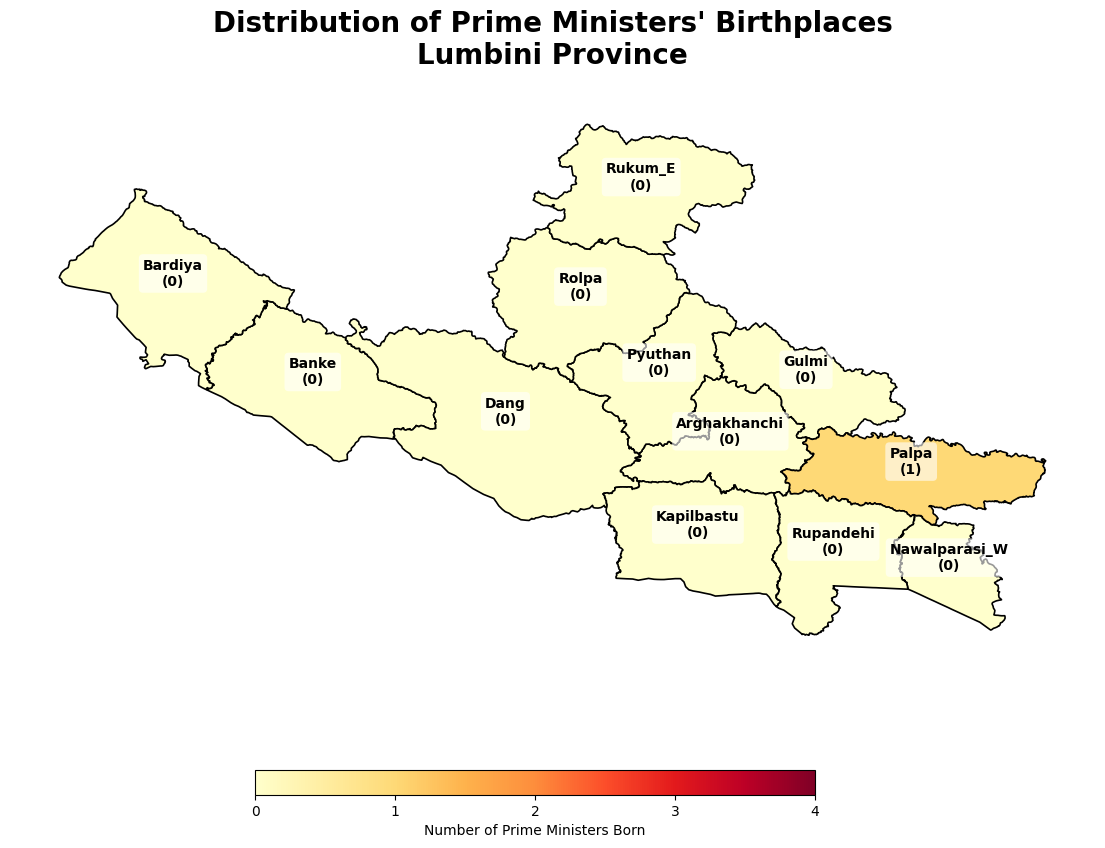

In [1]:
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def generate_professional_province_map():
    # 1. Official Naming and File Key Mapping
    # This ensures the Title and File looks professional
    province_info = {
        "1": {"name": "Koshi Province", "key": "1"},
        "2": {"name": "Madhesh Province", "key": "2"},
        "3": {"name": "Bagmati Province", "key": "Bagmati"},
        "4": {"name": "Gandaki Province", "key": "Gandaki"},
        "5": {"name": "Lumbini Province", "key": "5"},
        "6": {"name": "Karnali Province", "key": "Karnali"},
        "7": {"name": "Sudurpaschim Province", "key": "Sudur Pashchim"}
    }

    print("\n--- Nepal Prime Minister Birthplace Map Generator ---")
    for num, info in province_info.items():
        print(f"{num}. {info['name']}")
    
    choice = input("\nSelect Province Number (1-7): ").strip()
    
    if choice not in province_info:
        print("Invalid selection.")
        return

    selected_name = province_info[choice]['name']
    province_key = province_info[choice]['key']

    # 2. Load and Prepare Data
    df_pob = pd.read_csv('POB.csv')
    df_pob['Birthplace'] = df_pob['Birthplace'].str.strip().str.upper()
    df_pob['Birthplace'] = df_pob['Birthplace'].replace({'TEHRATHUM': 'TERHATHUM'})

    with open('localboundries.json', 'r') as f:
        data = json.load(f)
    gdf_local = gpd.GeoDataFrame.from_features(data['features'])
    
    gdf_local['DISTRICT'] = gdf_local['DISTRICT'].str.strip().str.upper()
    gdf_local['Province'] = gdf_local['Province'].astype(str).str.strip()

    # 3. Filter and Group
    gdf_filtered = gdf_local[gdf_local['Province'] == province_key]
    gdf_districts = gdf_filtered.dissolve(by='DISTRICT').reset_index()

    pm_counts = df_pob.groupby('Birthplace').size().reset_index(name='PM_Count')
    pm_counts.columns = ['DISTRICT', 'PM_Count']
    
    merged = gdf_districts.merge(pm_counts, on='DISTRICT', how='left')
    merged['PM_Count'] = merged['PM_Count'].fillna(0).astype(int)

    # 4. Visualization
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    
    # Consistent scale bar (0-4)
    cax = fig.add_axes([0.3, 0.08, 0.4, 0.025])

    merged.plot(
        column='PM_Count', 
        cmap='YlOrRd', 
        linewidth=1.2, 
        ax=ax, 
        edgecolor='black', 
        legend=True,
        cax=cax,
        vmin=0, 
        vmax=4,
        legend_kwds={'label': "Number of Prime Ministers Born", 'orientation': "horizontal"}
    )

    cax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # 5. Labeling Districts with proper Title Case
    merged['centroid'] = merged.geometry.centroid
    for idx, row in merged.iterrows():
        # Label format: "Kathmandu (4)"
        label_text = f"{row['DISTRICT'].title()}\n({row['PM_Count']})"
        ax.annotate(
            text=label_text, 
            xy=(row['centroid'].x, row['centroid'].y),
            horizontalalignment='center', 
            fontsize=10, 
            fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.3')
        )

    # PROFESSIONAL TITLE
    ax.set_title(f'Distribution of Prime Ministers\' Birthplaces\n{selected_name}', 
                 fontsize=20, fontweight='bold', pad=25)
    ax.axis('off')
    
    # 6. Save with requested naming format
    save_name = f'custom_province_{choice}_map.png'
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    print(f"\nSuccessfully generated: {save_name}")
    plt.show()

if __name__ == "__main__":
    generate_professional_province_map()

In [28]:
import json
import pandas as pd

def generate_pm_text_list(csv_path, json_path):
    # 1. Load the PM Data
    # We keep 'NA' as a string instead of letting pandas convert it to NaN
    df_pob = pd.read_csv(csv_path, keep_default_na=False)
    
    # 2. Load the Map Data to create a District -> Province lookup
    with open(json_path, 'r') as f:
        geo_data = json.load(f)

    # Build a lookup dictionary: {'DISTRICT': 'ProvinceName'}
    dist_to_prov = {}
    for feature in geo_data['features']:
        props = feature['properties']
        dist = props['DISTRICT'].strip().upper()
        prov = str(props['Province']).strip()
        dist_to_prov[dist] = prov

    # Map the JSON codes to official names
    province_names = {
        "1": "Koshi Province",
        "2": "Madhesh Province",
        "Bagmati": "Bagmati Province",
        "Gandaki": "Gandaki Province",
        "5": "Lumbini Province",
        "Karnali": "Karnali Province",
        "Sudur Pashchim": "Sudurpaschim Province"
    }

    # 3. Organize the PMs into groups
    # Keys will be Province Names, Born in India, or Unknown (NA)
    groups = {}

    for _, row in df_pob.iterrows():
        pm_name = row['PM']
        birthplace = row['Birthplace'].strip()
        birthplace_upper = birthplace.upper()
        
        # Handle spelling mismatch for Terhathum
        if birthplace_upper == "TEHRATHUM":
            birthplace_upper = "TERHATHUM"

        # Categorization logic
        if birthplace_upper == "INDIA":
            category = "Born in India"
            line = f"India : {pm_name}"
        elif birthplace_upper in ["NA", ""]:
            category = "Unknown (NA)"
            line = f"Location Unknown : {pm_name}"
        elif birthplace_upper in dist_to_prov:
            prov_code = dist_to_prov[birthplace_upper]
            category = province_names.get(prov_code, f"Province {prov_code}")
            line = f"{birthplace_upper.title()} : {pm_name}"
        else:
            category = "Other"
            line = f"{birthplace} : {pm_name}"

        if category not in groups:
            groups[category] = []
        groups[category].append(line)

    # 4. Final Output Formatting
    order = [
        "Koshi Province", "Madhesh Province", "Bagmati Province", 
        "Gandaki Province", "Lumbini Province", "Karnali Province", 
        "Sudurpaschim Province", "Born in India", "Unknown (NA)"
    ]

    for cat in order:
        if cat in groups:
            print(f"{cat}")
            for entry in groups[cat]:
                print(entry)
            print() # Blank line between provinces

# Run the program
generate_pm_text_list('POB.csv', 'localboundries.json')

Koshi Province
Dhankuta : Surya Bahadur Thapa
Dhankuta : Nagendra Prasad Rijal
Ilam : Jhala Nath Khanal
Morang : Sushil Koirala
Terhathum : K. P. Sharma Oli
Morang : Sushila Karki

Madhesh Province
Siraha : Tulsi Giri
Rautahat : Madhav Kumar Nepal

Bagmati Province
Kathmandu : Subarna Shamsher Rana
Kathmandu : Kirti Nidhi Bista
Kathmandu : Man Mohan Adhikari
Kathmandu : Balendra Shah

Gandaki Province
Kaski : Pushpa Kamal Dahal
Gorkha : Baburam Bhattarai

Lumbini Province
Palpa : Khil Raj Regmi

Karnali Province
Salyan : Marich Man Singh Shrestha

Sudurpaschim Province
Doti : Kunwar Indrajit Singh
Baitadi : Lokendra Bahadur Chand
Dadeldhura : Sher Bahadur Deuba

Born in India
India : Matrika Prasad Koirala
India : B. P. Koirala
India : Krishna Prasad Bhattarai
India : Girija Prasad Koirala

Unknown (NA)
Location Unknown : Tanka Prasad Acharya
Location Unknown : Gehendra Bahadur Rajbhandari

